In [1]:
import numpy as np
import numba
import numba.cuda as cuda
import matplotlib.pyplot as plt

from gpu import CRUs, RyR_stationary, LCC_stationary
from gpu.CRU3d import CRU3D
from params import RestrepoParams
from gpu.LCC import LCC_gillespie_test, LCC_kolmogorov_test

In [2]:
N = 20 * 20 * 60
vi = 0.5 * 19305 / N#10_000 / N
vs = vnsr = 0.05 * vi
vjsr = 0.02 * 19305 / N
vp = 0.001
params = RestrepoParams(Ku=1.4e-4, h=2.5, BCSQN=460.0, tau_u=145.0, vup=0.36, vi=vi, vs=vs, vnsr=vnsr, vjsr=vjsr, vp=vp)

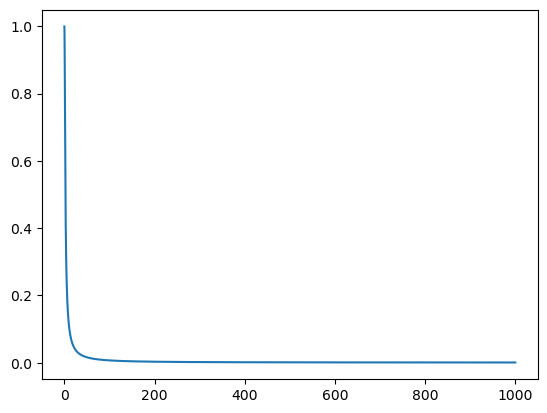

In [3]:
cjsr = np.linspace(0.1, 1000, num=10000)
rho = params.rho_inf / (1 + (params.K / cjsr) ** 2.5)
def Mhat_(rho, params):
    rhoBCSQN = rho * params.BCSQN
    return np.where(rhoBCSQN < 1e-10, 1.0 - 2.0 * rhoBCSQN, (np.sqrt(1.0 + 8.0 * rhoBCSQN) - 1.0) / (4.0 * rhoBCSQN))
Mhat = Mhat_(rho, params)
plt.plot(cjsr, Mhat)
plt.show()

In [4]:
rho

array([7.50624421e-07, 4.24617295e-06, 1.17010767e-05, ...,
       3.00039859e+03, 3.00069860e+03, 3.00099858e+03])

In [5]:
Mhat

array([9.99310378e-01, 9.96123747e-01, 9.89460724e-01, ...,
       6.01708175e-04, 6.01678103e-04, 6.01648040e-04])

In [6]:
ci = 0.2 * np.ones((60, 20, 20), dtype=np.float32)
cs = 0.2 * np.ones((60, 20, 20), dtype=np.float32)
cp = 0.2 * np.ones((60, 20, 20), dtype=np.float32)

cjsr = 1100.0 * np.ones((60, 20, 20), dtype=np.float32)
cnsr = 1100.0 * np.ones((60, 20, 20), dtype=np.float32)

CaTi = params.kon * params.BT * ci / (params.koff + params.kon * ci)
CaTs = params.kon * params.BT * cs / (params.koff + params.kon * cs)

RyR = np.zeros((60, 20, 20, 4), dtype=np.float32)
RyR[..., 0] = 1.0

LCC = np.ones((60, 20, 20, 4), dtype=np.int32)

vp = params.vp * np.ones_like(ci)

In [7]:
cru3d = CRU3D(params, RyR, LCC, ci, cnsr, cjsr, cs, cp, CaTi, CaTs, vp=vp)

In [8]:
sol = cru3d.forward(1e-2, T=400.0, Vmax=0.0, Vmin=-85.0, nstep=200_000, collect_every=200, tpb=(16,4,4))

In [9]:
sol.V

array([ 0.00000000e+00, -2.69291061e-03, -1.08263576e-02, ...,
       -8.50000000e+01, -8.50000000e+01, -8.50000000e+01])

In [10]:
ICa = sol.ICa
INCX = sol.INCX

/home/luke/GW-model/src/restrepo/gpu/CRU3d.py:109: RuntimeWarning: invalid value encountered in divide
  NLCC


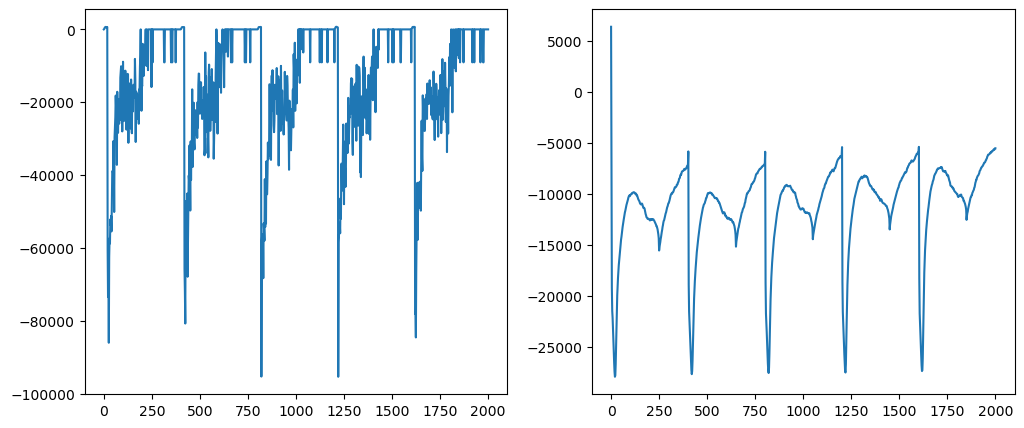

In [11]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
ax[0].plot(sol.t, ICa.sum(axis=(1,2,3)))
ax[1].plot(sol.t, INCX.sum(axis=(1,2,3)))
plt.show()

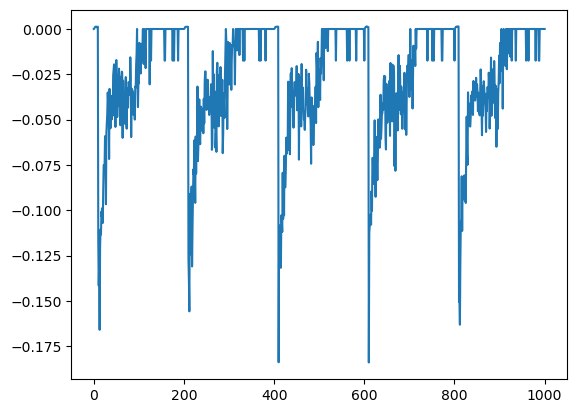

In [12]:
plt.plot(2*ICa.sum(axis=(1,2,3)) * params.vp * 1e-9 * 96.5 / (1e-4))
plt.show()

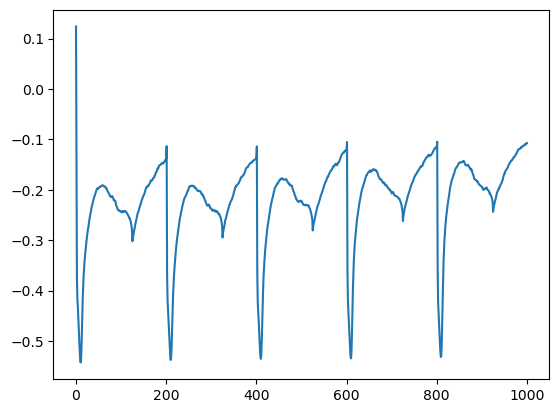

In [13]:
plt.plot(INCX.sum(axis=(1,2,3)) * params.vs * 1e-9 * 96.5 / (1e-4))
plt.show()

In [14]:
def check_Delta_ci(ci, params: RestrepoParams, junctional):
    Nx, Ny, Nz = ci.shape
    out = np.zeros_like(ci)
    for i in range(Nx):
        for j in range(Ny):
            for k in range(Nz):
                forward = ci[i+1, j, k] if i < (Nx - 1) else ci[i,j,k]
                backward = ci[i-1, j, k] if i > 0 else ci[i,j,k]
                right = ci[i, j+1, k] if j < (Ny - 1) else ci[i,j,k]
                left = ci[i, j-1, k] if j > 0 else ci[i,j,k]
                up = ci[i, j, k+1] if k < (Nz-1) else ci[i,j,k]
                down = ci[i, j, k-1] if k > 0 else ci[i,j,k]

                junctional_fwd = junctional[i, j, k] or junctional[i+1, j, k] if i < (Nx - 1) else junctional[i, j, k]
                junctional_backward = junctional[i, j, k] or junctional[i-1, j, k] if i > 0 else junctional[i, j, k]
                junctional_right = junctional[i, j, k] or junctional[i, j+1, k] if j < (Ny - 1) else junctional[i, j, k]
                junctional_left = junctional[i, j, k] or junctional[i, j-1, k] if j > 0 else junctional[i, j, k]
                junctional_up = junctional[i, j, k] or junctional[i, j, k+1] if k < (Nz - 1) else junctional[i, j, k]
                junctional_down = junctional[i, j, k] or junctional[i, j, k-1] if k > 0 else junctional[i, j, k]

                const_fwd = 1 / params.tau_iL_p if junctional_fwd else 1 / params.tau_iL_i
                const_backward = 1 / params.tau_iL_p if junctional_backward else 1 / params.tau_iL_i
                const_right = 1 / params.tau_iT_p if junctional_right else 1 / params.tau_iT_i
                const_left = 1 / params.tau_iT_p if junctional_left else 1 / params.tau_iT_i
                const_up = 1 / params.tau_iT_p if junctional_up else 1 / params.tau_iT_i
                const_down = 1 / params.tau_iT_p if junctional_down else 1 / params.tau_iT_i

                out[i, j, k] = ((forward - ci[i,j,k]) * const_fwd + (backward - ci[i,j,k]) * const_backward +
                                (right - ci[i,j, k]) * const_right + (left - ci[i, j, k]) * const_left +
                                (up - ci[i,j,k]) * const_up + (down - ci[i,j,k]) * const_down)
    return out
                
            

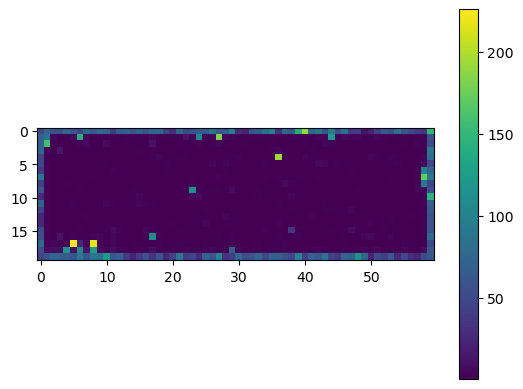

In [15]:
plt.imshow(sol.cp[10, ..., 10].T)
plt.colorbar()
plt.show()

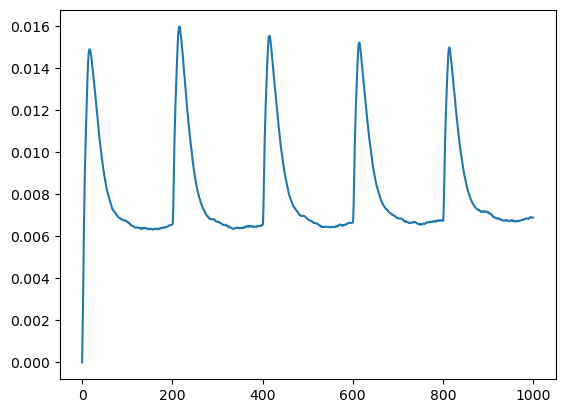

In [16]:
plt.plot(sol.RyR[..., 2].mean(axis=(1,2,3)) + sol.RyR[..., 3].mean(axis=(1,2,3)))
plt.show()

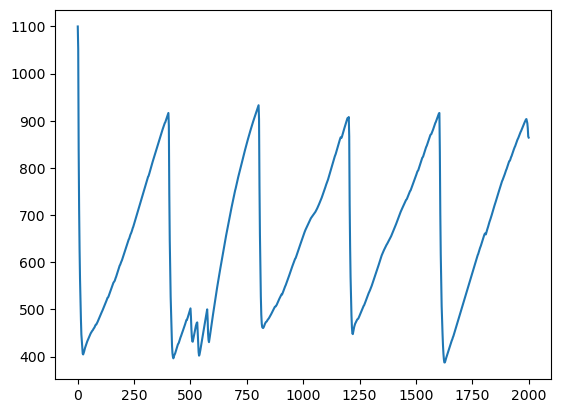

In [17]:
plt.plot(sol.t, sol.cjsr[:, 0,0,-1])
plt.show()

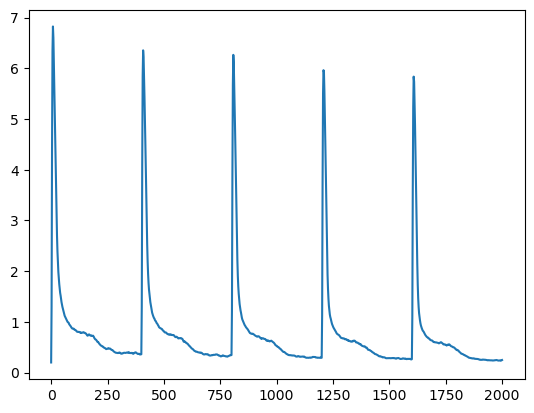

In [26]:
plt.plot(sol.t, sol.cs.mean(axis=(1,2,3)))
plt.show()

In [77]:
params.vs / params.vi

0.05

In [9]:
ci = 0.2 * np.ones((200, 200), dtype=np.float32)
cs = 0.2 * np.ones((200, 200), dtype=np.float32)
cp = 0.2 * np.ones((200, 200), dtype=np.float32)

cjsr = 1100.0 * np.ones((200,200), dtype=np.float32)
cnsr = 1100.0 * np.ones((200,200), dtype=np.float32)

CaTi = 17.5 * np.ones((200,200), dtype=np.float32)
CaTs = 17.5 * np.ones((200,200), dtype=np.float32)

vp = params.vp * np.ones_like(ci)

In [10]:
RyR = RyR_stationary(cp, params)

In [11]:
#LCC = LCC_stationary(cp, 0.1, params)
LCC = np.zeros((*cp.shape, 4), dtype=np.int32)
LCC[0, ...] = 1
LCC[-1, ...] = 1
LCC[:, 0, :] = 1
LCC[:, -1, :] = 1

In [12]:
cru_obj = CRUs(params, RyR, LCC, ci, cnsr, cjsr, cs, cp, CaTi, CaTs, vp=vp)

In [13]:
cru_obj.forward(dt=1e-2, nstep=100_000, collect_every=1000, tpb2d=(8,8), tpb1d=16)

/home/luke/anaconda3/lib/python3.11/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 50 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


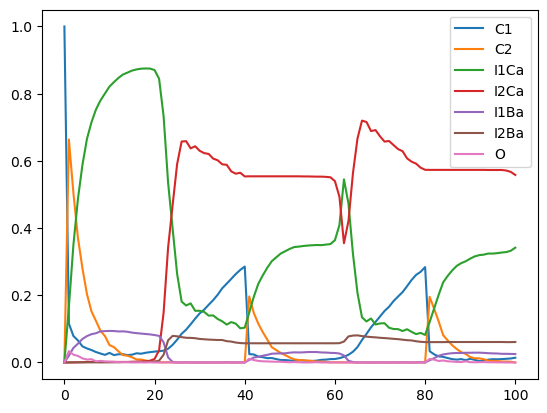

In [14]:
plt.plot((cru_obj.LCC_result == 1).sum(axis=(1,2,3)) / (796*4), label="C1")
plt.plot((cru_obj.LCC_result == 2).sum(axis=(1,2,3)) / (796*4), label="C2")
plt.plot((cru_obj.LCC_result == 3).sum(axis=(1,2,3)) / (796*4), label="I1Ca")
plt.plot((cru_obj.LCC_result == 4).sum(axis=(1,2,3)) / (796*4), label="I2Ca")
plt.plot((cru_obj.LCC_result == 5).sum(axis=(1,2,3)) / (796*4), label="I1Ba")
plt.plot((cru_obj.LCC_result == 6).sum(axis=(1,2,3)) / (796*4), label="I2Ba")
plt.plot((cru_obj.LCC_result == 7).sum(axis=(1,2,3)) / (796*4), label="O")
plt.legend()
plt.show()

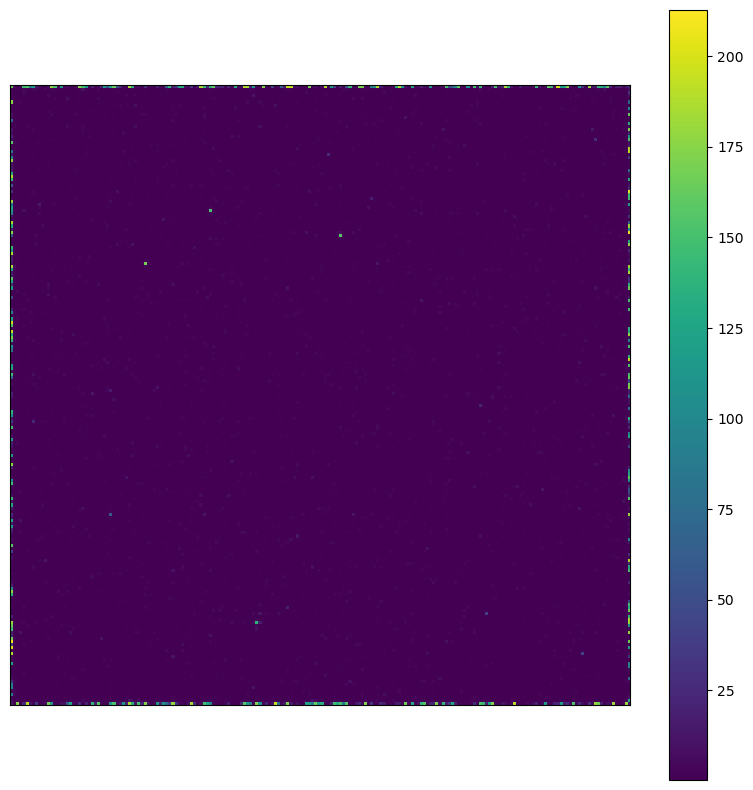

In [20]:
fig, ax = plt.subplots(1, figsize=(10,10))
im = ax.imshow(cru_obj.cp_result[1, ...], aspect='equal')
ax.set_yticks([])
ax.set_xticks([])
fig.colorbar(im)
plt.show()

In [17]:
ci_bdy = (cru_obj.ci_result[:, 0, :] + cru_obj.ci_result[:, -1, :] + cru_obj.ci_result[:, :, 0] + cru_obj.ci_result[:, :, -1]).sum(axis=1)

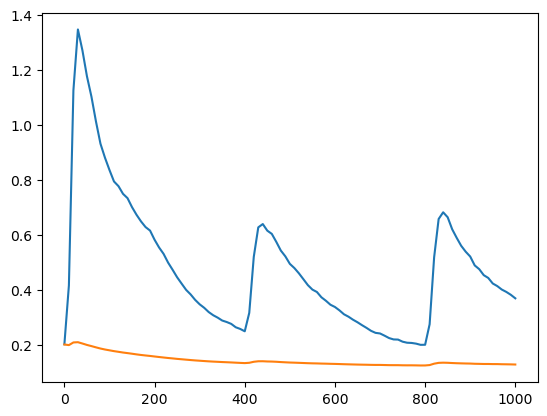

In [18]:
plt.plot(cru_obj.t, ci_bdy / (2*200 + 2*198))
plt.plot(cru_obj.t, cru_obj.ci_result.mean(axis=(1,2)))
plt.show()

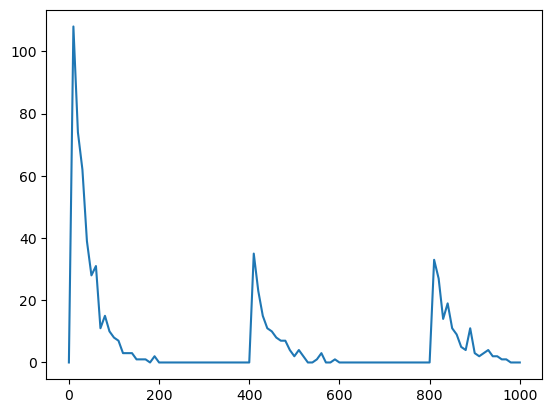

In [19]:
plt.plot(cru_obj.t, (cru_obj.LCC_result == 7).sum(axis=(1,2,3)))
plt.show()

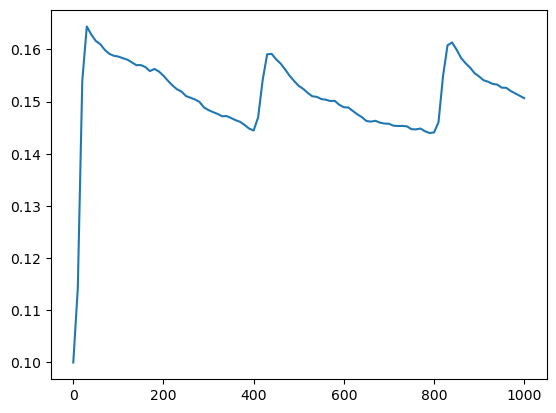

In [32]:
plt.plot(cru_obj.t, cru_obj.ci_result.mean(axis=(1,2)))
plt.show()

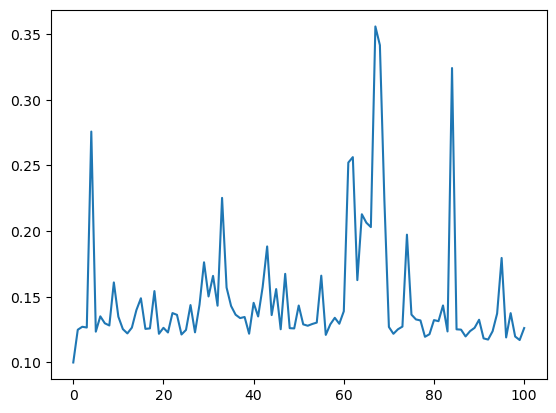

In [25]:
plt.plot(cru_obj.t, cru_obj.cs_result[:,10,10])
plt.show()

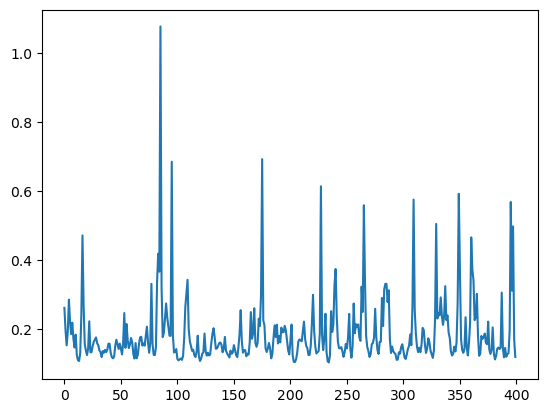

In [12]:
plt.plot(cru_obj.ci_result[-1, -1, :])
plt.show()

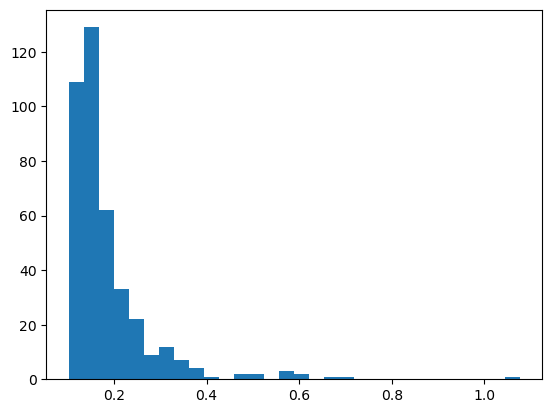

In [13]:
plt.hist(cru_obj.ci_result[-1, -1, :], bins=30)
plt.show()

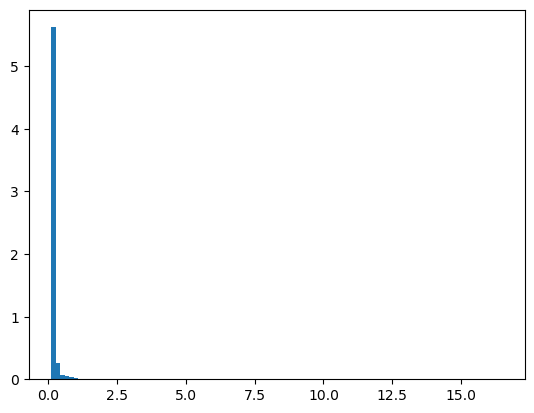

In [14]:
plt.hist(cru_obj.cs.reshape(-1), bins=100, density=True)
plt.show()

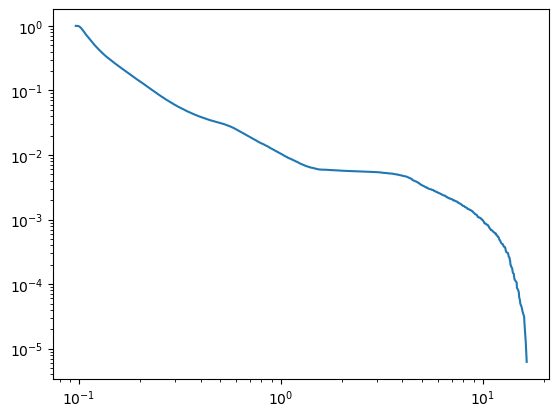

In [15]:
def ccdf(arr):
    ps = np.arange(1, len(arr)+1) / len(arr)
    vals = np.sort(arr)[::-1]
    return ps, vals

ps, bins = ccdf(cru_obj.cs.reshape(-1))
plt.plot(bins, ps)
plt.xscale('log')
plt.yscale('log')
plt.show()

In [16]:
from scipy.fft import fft2, ifft2, fftfreq, fftshift, ifftshift

In [17]:
modes = ifftshift(fft2(fftshift((cru_obj.ci - cru_obj.ci.mean())), norm="ortho"))

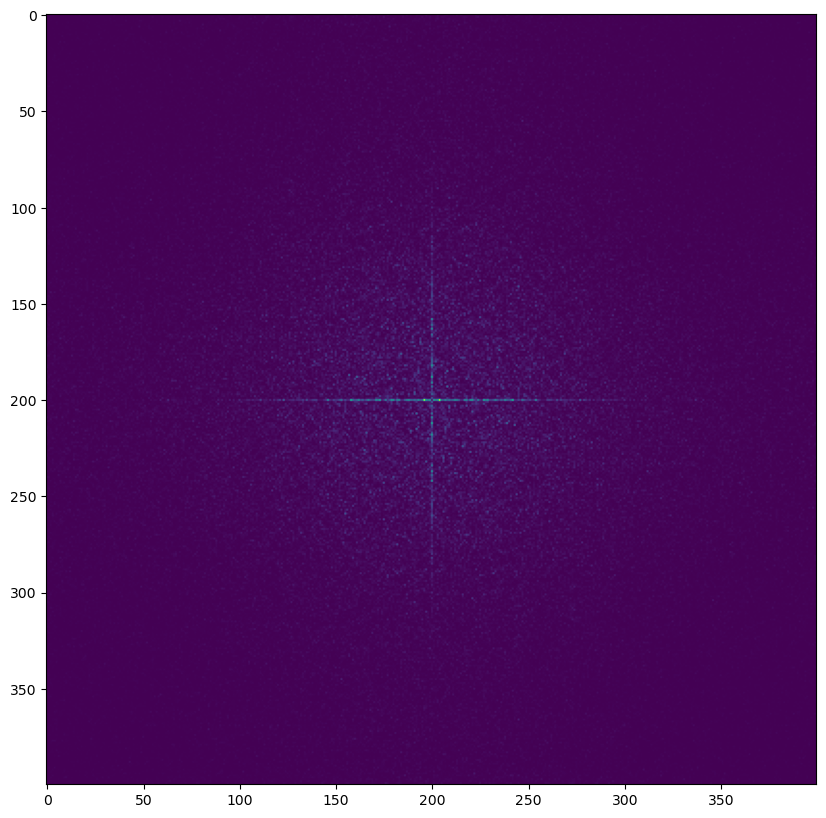

In [18]:
fig, ax = plt.subplots(1, figsize=(10,10))
ax.imshow(np.abs(modes)**2)
plt.show()

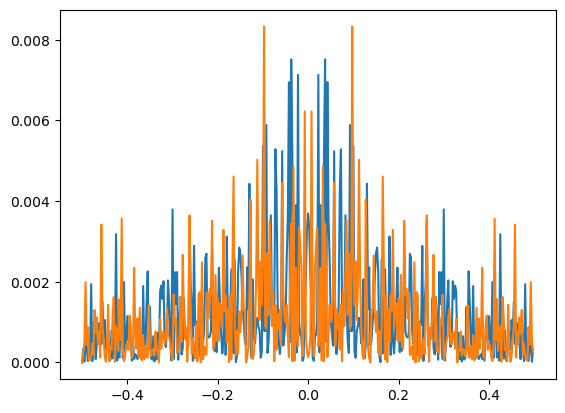

In [19]:
freqs = fftshift(fftfreq(modes[0,:].shape[0]))
plt.plot(freqs, np.abs(modes)[:, 0]**2)
plt.plot(freqs, np.abs(modes)[0, :]**2)
plt.show()

In [20]:
autocor = ifftshift(ifft2(fftshift(np.abs(modes)**2), norm="ortho"))

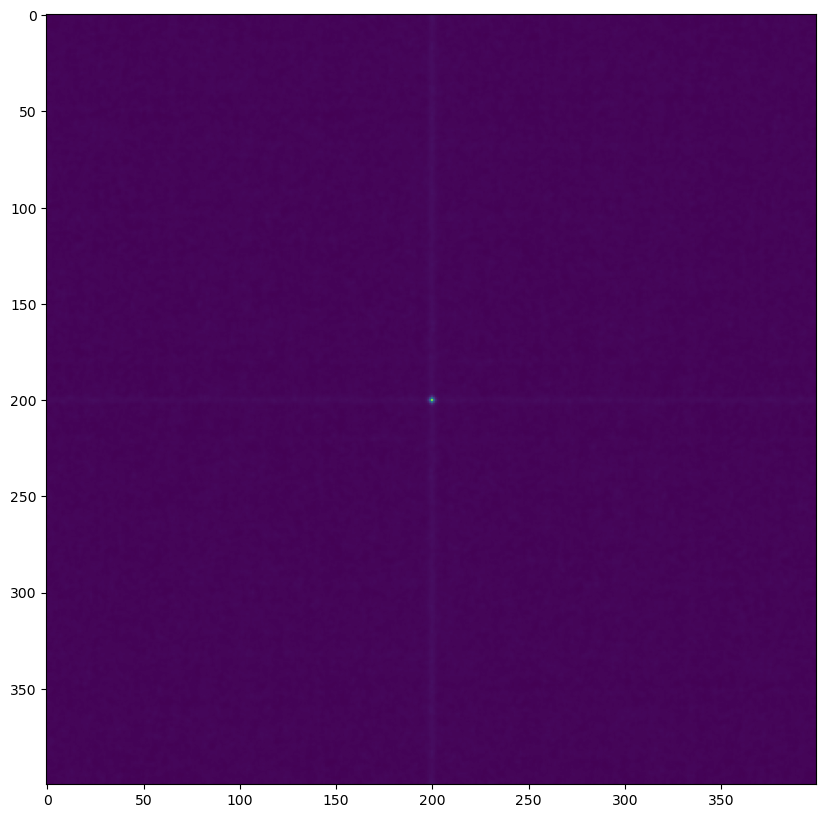

In [21]:
fig, ax = plt.subplots(1, figsize=(10,10))
ax.imshow(autocor.real)
plt.show()

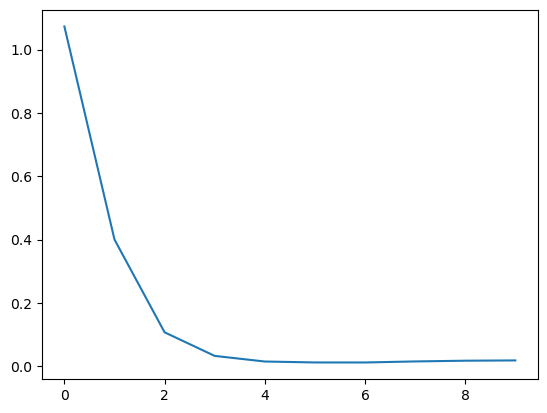

In [22]:
plt.plot(autocor[autocor.shape[0]//2, (autocor.shape[0]//2):(autocor.shape[0]//2+10)].real)
plt.show()